<a href="https://colab.research.google.com/github/Deepanshu-Malakar/Learn_Machine_Learning/blob/main/003_Pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setting up Pytorch to build neural network**

In [1]:
import torch
from torch import nn  #nn stands for neural network
import numpy as np
import matplotlib.pyplot as plt


# **Setting up GPU if available**

In [2]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


#**Preparing and loading Data**<br>
data in machine learning can be anything that can be represented in numbers.

Build a **known** dataset using linear regression
linear regression
Y=a+bX
create weight and baises<br>
here **a** is **bias** and **b** is **weight**

In [3]:
weight =0.7
bais = 0.3
x=torch.arange(0.,50.,1.)
print(x)
y=weight*x + bais
print(y)


tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27.,
        28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41.,
        42., 43., 44., 45., 46., 47., 48., 49.])
tensor([ 0.3000,  1.0000,  1.7000,  2.4000,  3.1000,  3.8000,  4.5000,  5.2000,
         5.9000,  6.6000,  7.3000,  8.0000,  8.7000,  9.4000, 10.1000, 10.8000,
        11.5000, 12.2000, 12.9000, 13.6000, 14.3000, 15.0000, 15.7000, 16.4000,
        17.1000, 17.8000, 18.5000, 19.2000, 19.9000, 20.6000, 21.3000, 22.0000,
        22.7000, 23.4000, 24.1000, 24.8000, 25.5000, 26.2000, 26.9000, 27.6000,
        28.3000, 29.0000, 29.7000, 30.4000, 31.1000, 31.8000, 32.5000, 33.2000,
        33.9000, 34.6000])


Splitting the data into training data and testing data

80% of the data will be used for training and remaining for testing

In [9]:
train_split = int(0.8*len(x))
x_train=x[:train_split]
y_train=y[:train_split]

x_test=x[train_split:]
y_test=y[train_split:]

print("X train:")
print(x_train)
print("X test:")
print(x_test)
print("Y train:")
print(y_train)
print("Y test:")
print(y_test)

X train:
tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27.,
        28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39.])
X test:
tensor([40., 41., 42., 43., 44., 45., 46., 47., 48., 49.])
Y train:
tensor([ 0.3000,  1.0000,  1.7000,  2.4000,  3.1000,  3.8000,  4.5000,  5.2000,
         5.9000,  6.6000,  7.3000,  8.0000,  8.7000,  9.4000, 10.1000, 10.8000,
        11.5000, 12.2000, 12.9000, 13.6000, 14.3000, 15.0000, 15.7000, 16.4000,
        17.1000, 17.8000, 18.5000, 19.2000, 19.9000, 20.6000, 21.3000, 22.0000,
        22.7000, 23.4000, 24.1000, 24.8000, 25.5000, 26.2000, 26.9000, 27.6000])
Y test:
tensor([28.3000, 29.0000, 29.7000, 30.4000, 31.1000, 31.8000, 32.5000, 33.2000,
        33.9000, 34.6000])


Plotting our predictions

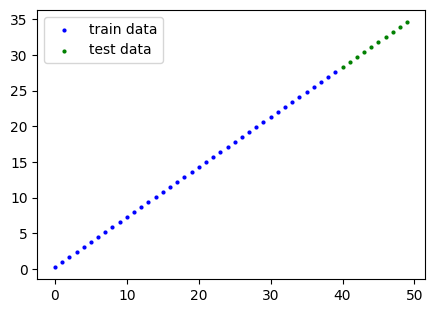

In [22]:
def plot(train_data,train_label,test_data,test_label,y_predicted=None):
  plt.figure(figsize=(10*0.5,7*0.5))


  plt.scatter(train_data,train_label,c="b",s=4,label="train data")
  plt.scatter(test_data,test_label,c="g",s=4,label="test data")

  if y_predicted is not None:
    plt.scatter(test_data,y_predicted,c="r",s=4,label="Predictions")

  plt.legend()
plot(x_train,y_train,x_test,y_test)

# Build a Linear Regression Model

In [23]:
#create a linear regression model class

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.weight=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
    self.bias=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))

  def forward(self,x:torch.Tensor)->torch.Tensor:
    return x*self.weight + self.bias

torch.manual_seed(42)
model0=LinearRegressionModel()
list(model0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

**making predictions**

In [24]:
print(f"x={x_test}\ny={y_test}")

x=tensor([40., 41., 42., 43., 44., 45., 46., 47., 48., 49.])
y=tensor([28.3000, 29.0000, 29.7000, 30.4000, 31.1000, 31.8000, 32.5000, 33.2000,
        33.9000, 34.6000])


In [25]:
with torch.inference_mode():
  y_preds = model0(x_test)
y_preds

tensor([13.5964, 13.9331, 14.2698, 14.6065, 14.9432, 15.2799, 15.6166, 15.9533,
        16.2899, 16.6266])

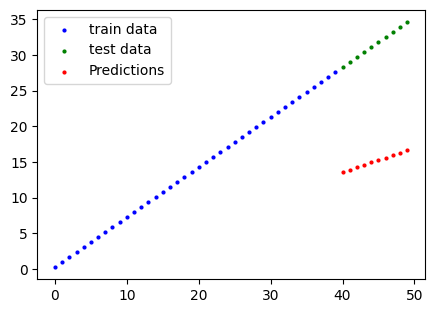

In [26]:
plot(x_train,y_train,x_test,y_test,y_preds)

We can see above that the predicted values are not matching wiht the test values